<a href="https://colab.research.google.com/github/abhinendra9792/Data-Science-ML/blob/main/Minor_Project_01_EDA_Telco_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minor Project 01 — Exploratory Data Analysis
### Course: CSB314 — Exploratory Data Analysis  
### Dataset: Telco Customer Churn

---

## Analytical Question

**Which customer attributes are most strongly associated with
customer churn in a telecom subscriber base?**

This project uses Exploratory Data Analysis to examine how contract
type, tenure, service subscriptions, and billing amounts relate to
whether a customer leaves the service.

---

## Objective

- Apply a structured EDA workflow to a real-world dataset.
- Classify variables as numerical, categorical, ordinal, or time-related.
- Demonstrate NumPy array creation, indexing, reshaping, vectorization,
  broadcasting, aggregation, Boolean and fancy indexing, and seeded
  random-number generation.
- Produce meaningful visualisations and interpret them with evidence.
- Communicate findings while distinguishing association from causation.

---

## Dataset Source and Description

| Field | Detail |
|---|---|
| Dataset Name | Telco Customer Churn |
| Source | Kaggle |
| URL | https://www.kaggle.com/datasets/blastchar/telco-customer-churn |
| Access Date | 27 August 2026 |
| Rows | 7,043 |
| Columns | 21 |
| File | `telco_churn.csv` |

Each row represents one telecom customer. The columns record demographic
details, the services the customer subscribes to, contract and billing
information, and whether the customer churned.

### Important Columns

| Column | Meaning |
|---|---|
| `customerID` | Anonymous identifier for each customer |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Customer demographics |
| `tenure` | Number of months the customer has stayed with the company |
| `PhoneService`, `InternetService`, `OnlineSecurity`, `TechSupport`, `StreamingTV` | Services subscribed to |
| `Contract` | Month-to-month, One year, or Two year |
| `PaperlessBilling`, `PaymentMethod` | Billing preferences |
| `MonthlyCharges` | Amount billed to the customer each month |
| `TotalCharges` | Total amount billed over the customer's full tenure |
| `Churn` | Whether the customer left the service (Yes / No) |

### Expected Value of Performing EDA

Before any predictive modelling, EDA reveals the structure and condition
of the data. For this dataset it shows how churn is distributed across
contract types, whether tenure and charges differ between customers who
leave and those who stay, and which columns contain missing or
incorrectly typed values. Notably, `TotalCharges` is stored as text
rather than a number, an issue that would silently corrupt any later
analysis if left undetected. EDA surfaces such problems early and
guides which relationships deserve closer investigation.

In [61]:
import os, shutil

# Ensure the dataset is available in the working directory.
# Safe to re-run: only moves the file if it is not already in place.
if not os.path.exists("telco_churn.csv") and os.path.exists("/telco_churn.csv"):
    shutil.move("/telco_churn.csv", "telco_churn.csv")

print("Dataset present:", os.path.exists("telco_churn.csv"))

Dataset present: True


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("telco_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Import Required Libraries

The Python data-science ecosystem divides the work of an EDA project
across several specialised libraries. Each is imported below under its
conventional alias.

| Library | Role in this project |
|---|---|
| **NumPy** | Provides the `ndarray`, a fixed-type array stored in contiguous memory. It performs vectorized numerical computation, broadcasting, and axis-based aggregation far faster than Python lists. Every array demonstration in this project uses NumPy. |
| **Pandas** | Adds labelled tabular structures (`DataFrame`, `Series`) built on top of NumPy. It handles reading the CSV, inspecting column types, summarising statistics, counting categories, and detecting missing or duplicate records. |
| **Matplotlib** | The foundational plotting library. It controls figures, axes, titles, and labels, and every other plotting library in this project ultimately draws through it. |
| **Seaborn** | A statistical layer built over Matplotlib. It produces grouped and distribution plots directly from a DataFrame with far less code, and applies sensible default styling. |
| **Plotly** | Generates interactive charts that support hovering and zooming. It is most useful for exploration in a browser; this project relies mainly on Matplotlib and Seaborn, which are sufficient for the static plots required here. |

In short: **NumPy computes, Pandas organises, Matplotlib draws,
Seaborn summarises statistically, and Plotly adds interactivity.**

## Jupyter Notebook Documentation

A Jupyter Notebook stores code, its output, and explanatory Markdown in
a single document. This differs from a plain Python script, which
contains only code and produces output separately. For exploratory
work the notebook format matters because each result stays attached to
the code that produced it and to the reasoning about what it means,
making the analysis reproducible and readable by others.

Throughout this notebook, Markdown cells state what each step is doing
and why, and observations are written beneath the outputs they describe
rather than as inline code comments.

## Dataset Loading

The dataset is loaded from the uploaded CSV file using a relative path,
so the notebook does not depend on any absolute local file location.
The shape confirms **7,043 rows and 21 columns**, where each row is one
telecom customer.

---

## Data Understanding

Before analysing anything, the structure of the dataset is inspected:
how many rows and columns exist, what data type Pandas has assigned to
each column, and what the numerical columns look like statistically.
This step determines which columns are usable as-is and which need
attention before analysis.

In [63]:
# Number of rows and columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names, non-null counts, and data types
df.info()

Rows: 7043
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

### Summary Statistics and Category Overview

Numerical columns are summarised using `describe()`, which reports
count, mean, standard deviation, minimum, quartiles, and maximum.
Categorical columns are examined through value counts, which show how
many customers fall into each category.

Note from the output above that `TotalCharges` is typed as `object`
rather than a numeric type, even though it holds monetary values.
This is investigated in the Data Quality section.

In [64]:
# Summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [65]:
# Frequency counts for key categorical columns
for col in ["gender", "Contract", "InternetService", "PaymentMethod", "Churn"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--- Churn ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64



**Observations from the summary statistics and category counts:**

- Average tenure is about **32.4 months** with a standard deviation of
  **24.6 months**, so customer lifetimes are widely spread rather than
  clustered around the mean.
- `MonthlyCharges` averages about **₹64.8** (dataset currency units)
  with a standard deviation of **30.1**, indicating a broad range of
  service plans rather than one dominant price point.
- `SeniorCitizen` has a mean of **0.162**, meaning roughly **16%** of
  customers are senior citizens. It is stored as 0/1 but is a
  categorical flag, not a true numerical measurement.
- Gender is nearly balanced: **3,555 male** and **3,488 female**
  customers.
- **Month-to-month is the dominant contract type (3,875 customers)** —
  more than one- and two-year contracts combined.
- **Fiber optic (3,096)** is the most common internet service, while
  **1,526 customers have no internet service at all**, which explains
  why several service columns contain a "No internet service" category.

## Data-Type Classification

Each relevant column is classified by the type of information it
carries, which determines what analysis is valid for it.

| Column | Classification | Reason |
|---|---|---|
| `tenure` | Numerical (discrete) | A count of whole months; averaging is meaningful |
| `MonthlyCharges` | Numerical (continuous) | A measured amount that can take any value in a range |
| `TotalCharges` | Numerical (continuous) | Currently stored as text; must be converted before use |
| `SeniorCitizen` | Categorical (binary) | Stored as 0/1 but represents a yes/no flag, not a quantity |
| `gender`, `Partner`, `Dependents` | Categorical (nominal) | Labels with no natural ordering |
| `InternetService`, `PaymentMethod` | Categorical (nominal) | Service and payment types with no inherent rank |
| `Contract` | **Ordinal** | Month-to-month → One year → Two year has a natural order of increasing commitment |
| `Churn` | Categorical (binary) | The target attribute: Yes / No |
| `customerID` | Identifier | A unique code; carries no analytical information and is excluded |
| — | Time-series | **Not applicable.** No datetime column exists. `tenure` measures duration in months, but the dataset is a single snapshot rather than observations ordered in time. |

**Columns most relevant to the analytical question:** `Contract`,
`tenure`, `MonthlyCharges`, `TotalCharges`, and `InternetService`, since
these describe commitment level, customer lifetime, and cost — the
factors most plausibly linked to a decision to leave.

## Data Quality Exploration

Before analysis, the dataset is checked for missing values, duplicate
records, and columns whose stored type does not match the information
they hold. Problems found at this stage would otherwise distort every
later calculation.

In [66]:
# Missing values per column
print("Missing values per column:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Duplicate customer IDs
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0
Duplicate customerIDs: 0


In [67]:
# TotalCharges is stored as text; find which values cannot convert to a number
converted = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad_rows = df[converted.isnull()]

print("Rows where TotalCharges is not numeric:", len(bad_rows))
print("\nTenure values in those rows:", bad_rows["tenure"].unique())
bad_rows[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head()

Rows where TotalCharges is not numeric: 11

Tenure values in those rows: [0]


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No


In [68]:
# Convert TotalCharges to numeric; blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# These blanks belong to customers with tenure = 0, who have not yet
# been billed. Their true total charge is 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)
print("Missing values remaining:", df["TotalCharges"].isnull().sum())

TotalCharges dtype after conversion: float64
Missing values remaining: 0


**Data quality findings:**

- **No missing values** appear in any of the 21 columns when the file is
  first loaded, and there are **no duplicate rows or duplicate
  `customerID` values**. Every row represents a distinct customer.
- However, **`TotalCharges` was stored as `object` (text) rather than a
  number.** This is a silent data-quality problem: the column looks
  usable but cannot be averaged or plotted numerically.
- The cause is **11 rows containing a blank string**. Every one of these
  rows has **`tenure = 0`** — these are newly joined customers who have
  not yet been billed for a full cycle.
- Because a customer billed for zero months has genuinely accumulated
  zero total charges, these blanks were filled with **0** rather than
  dropped. This preserves all 7,043 rows and avoids removing an entire
  customer segment from the analysis.
- After conversion, `TotalCharges` is `float64` with **0 missing
  values** and is ready for numerical analysis.

This illustrates why EDA precedes modelling: the standard
`isnull().sum()` check reported no missing data, yet the column was
unusable until its stored type was examined.

### Which Variables to Explore Visually

The exploration above points to three relationships worth visualising:

1. **`MonthlyCharges`** shows a wide spread (std ≈ 30.1) with no single
   dominant price point, so its distribution is worth examining directly.
2. **`Contract`** is heavily skewed toward month-to-month customers
   (3,875 of 7,043), and since contract length represents commitment, its
   relationship with `Churn` is the most promising categorical comparison.
3. **`tenure` and `TotalCharges`** are mechanically linked (longer tenure
   accumulates more charges), so plotting them together and colouring by
   churn should reveal whether churners differ in customer lifetime.

`customerID` is excluded as a pure identifier, and `gender` is nearly
balanced (3,555 / 3,488), making it unlikely to separate the groups.

# 3. NumPy Array Demonstrations

## Array Creation

NumPy's `ndarray` is a fixed-type, contiguously stored array. Unlike a
Python list, every element shares one data type and one memory block,
which is what allows operations to run at compiled speed rather than
through a Python loop.

Five creation methods are demonstrated below. Two build arrays directly
from the dataset, and three construct arrays from specification —
useful for placeholders, sequences, and evenly spaced ranges.

In [69]:
# 1. np.array() — build an array from existing data (dataset columns)
tenure_arr = np.array(df["tenure"])
charges_arr = np.array(df["MonthlyCharges"])
print("np.array() from tenure column:", tenure_arr[:8])

# 2. np.zeros() — placeholder array of zeros
zeros_arr = np.zeros(5)
print("np.zeros(5):", zeros_arr)

# 3. np.ones() — placeholder array of ones, shaped 2x4
ones_arr = np.ones((2, 4))
print("np.ones((2,4)):\n", ones_arr)

# 4. np.arange() — sequence with a fixed step
arange_arr = np.arange(0, 73, 12)   # tenure milestones, yearly
print("np.arange(0,73,12):", arange_arr)

# 5. np.linspace() — evenly spaced values between two endpoints
linspace_arr = np.linspace(df["MonthlyCharges"].min(),
                           df["MonthlyCharges"].max(), 6)
print("np.linspace over MonthlyCharges range:", np.round(linspace_arr, 2))

np.array() from tenure column: [ 1 34  2 45  2  8 22 10]
np.zeros(5): [0. 0. 0. 0. 0.]
np.ones((2,4)):
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]]
np.arange(0,73,12): [ 0 12 24 36 48 60 72]
np.linspace over MonthlyCharges range: [ 18.25  38.35  58.45  78.55  98.65 118.75]


**Notes on each method:**

- `np.array()` converts existing data into an array. Here it pulls the
  `tenure` and `MonthlyCharges` columns out of the DataFrame so they can
  be used in pure NumPy operations.
- `np.zeros()` and `np.ones()` create arrays of a given shape without
  needing source data. They are typically used to pre-allocate space
  before filling it, or as neutral starting values.
- `np.arange()` produces a sequence with a fixed step. The step of 12
  here marks yearly tenure milestones from 0 to 72 months.
- `np.linspace()` divides a range into a fixed *number* of evenly spaced
  points, rather than stepping by a fixed amount. It is used here to
  generate six cut points across the observed billing range — the
  natural choice when the count of points matters more than the gap
  between them.

The practical distinction: **`arange` fixes the step size, `linspace`
fixes the number of points.**

## Array Properties, Indexing and Slicing

Every NumPy array carries metadata describing its structure and memory
footprint. These five attributes are inspected below.

| Attribute | Meaning |
|---|---|
| `shape` | Size along each dimension, as a tuple |
| `ndim` | Number of dimensions (1 for a vector, 2 for a matrix) |
| `dtype` | The single data type shared by every element |
| `size` | Total number of elements across all dimensions |
| `itemsize` | Bytes occupied by **one** element |

Total memory used by the array's data is therefore
$$\text{bytes} = \text{size} \times \text{itemsize}$$

In [70]:
# A 2D array built from three numerical dataset columns
numeric_2d = df[["tenure", "MonthlyCharges", "TotalCharges"]].to_numpy()

for name, arr in [("tenure_arr (1D)", tenure_arr),
                  ("numeric_2d (2D)", numeric_2d)]:
    print(f"--- {name} ---")
    print("shape    :", arr.shape)
    print("ndim     :", arr.ndim)
    print("dtype    :", arr.dtype)
    print("size     :", arr.size)
    print("itemsize :", arr.itemsize, "bytes")
    print("total    :", arr.size * arr.itemsize, "bytes")
    print()

--- tenure_arr (1D) ---
shape    : (7043,)
ndim     : 1
dtype    : int64
size     : 7043
itemsize : 8 bytes
total    : 56344 bytes

--- numeric_2d (2D) ---
shape    : (7043, 3)
ndim     : 2
dtype    : float64
size     : 21129
itemsize : 8 bytes
total    : 169032 bytes



**Observations:**

- `tenure_arr` has shape `(7043,)` and `ndim = 1` — a single row of
  7,043 month-counts. Its `dtype` is `int64`, since tenure is a whole
  number of months.
- `numeric_2d` has shape `(7043, 3)` and `ndim = 2` — 7,043 customers
  down the rows, three measurements across the columns.
- Its `dtype` is `float64`, not `int64`. NumPy requires one type for the
  whole array, so combining the integer `tenure` with the decimal
  charge columns **promotes** every value to float. This is a direct
  consequence of the fixed-type design.
- `itemsize` is **8 bytes** for both, as `int64` and `float64` each
  occupy 64 bits.
- `numeric_2d` holds `size = 21,129` elements, so its data occupies
  roughly **169 KB** — small enough to work with comfortably in memory.

This is also why `size` and `shape` differ: `shape` describes the
layout, while `size` counts every element regardless of arrangement.

### Indexing and Slicing

Indexing retrieves a single element by position; slicing retrieves a
range using `start:stop:step`, where `stop` is exclusive. NumPy indexing
is zero-based, and negative indices count backwards from the end.

For a 2D array the syntax is `arr[row, column]`, which is more direct
than the chained `arr[row][column]` used with nested Python lists.

In [71]:
# --- 1D indexing and slicing on tenure_arr ---
print("First element        :", tenure_arr[0])
print("Fifth element        :", tenure_arr[4])
print("Last element         :", tenure_arr[-1])
print("First 10 values      :", tenure_arr[:10])
print("Elements 100 to 105  :", tenure_arr[100:106])
print("Every 1000th value   :", tenure_arr[::1000])
print("Reversed (first 5)   :", tenure_arr[::-1][:5])

First element        : 1
Fifth element        : 2
Last element         : 66
First 10 values      : [ 1 34  2 45  2  8 22 10 28 62]
Elements 100 to 105  : [ 1  1 38 66 68  5]
Every 1000th value   : [ 1  7  9 12 39  6 52 67]
Reversed (first 5)   : [66  4 11 72 24]


In [72]:
# --- 2D indexing and slicing on numeric_2d ---
# Columns are: 0 = tenure, 1 = MonthlyCharges, 2 = TotalCharges

print("Single element [0, 1] (first customer's MonthlyCharges):",
      numeric_2d[0, 1])

print("\nEntire first row (one customer's three measures):\n",
      numeric_2d[0])

print("\nEntire column 1 — first 8 MonthlyCharges values:\n",
      numeric_2d[:, 1][:8])

print("\nFirst 4 rows, first 2 columns:\n",
      numeric_2d[:4, :2])

print("\nLast 3 rows, all columns:\n",
      numeric_2d[-3:, :])

Single element [0, 1] (first customer's MonthlyCharges): 29.85

Entire first row (one customer's three measures):
 [ 1.   29.85 29.85]

Entire column 1 — first 8 MonthlyCharges values:
 [29.85 56.95 53.85 42.3  70.7  99.65 89.1  29.75]

First 4 rows, first 2 columns:
 [[ 1.   29.85]
 [34.   56.95]
 [ 2.   53.85]
 [45.   42.3 ]]

Last 3 rows, all columns:
 [[1.1000e+01 2.9600e+01 3.4645e+02]
 [4.0000e+00 7.4400e+01 3.0660e+02]
 [6.6000e+01 1.0565e+02 6.8445e+03]]


In [73]:
# --- n-dimensional array (3D) ---
# TotalCharges is re-checked here so this cell works regardless of the
# order in which earlier cells were executed.
if df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],
                                       errors="coerce").fillna(0)
    print("TotalCharges converted to numeric.")

numeric_2d = df[["tenure", "MonthlyCharges", "TotalCharges"]].to_numpy(dtype=float)

# Reshape into 4 blocks of equal size. Rows that do not divide evenly
# are dropped, since reshape requires an exact element count.
n_blocks   = 4
rows_used  = (len(numeric_2d) // n_blocks) * n_blocks
numeric_3d = numeric_2d[:rows_used].reshape(n_blocks, rows_used // n_blocks, 3)

print("Rows used:", rows_used, "of", len(numeric_2d))
print("3D shape:", numeric_3d.shape, "| ndim:", numeric_3d.ndim,
      "| dtype:", numeric_3d.dtype)

# Indexing: block 0, customer 5, column 1 (MonthlyCharges)
print("\nBlock 0, customer 5, MonthlyCharges:", numeric_3d[0, 5, 1])

# Slicing: first 3 customers of block 2, all columns
print("\nBlock 2, first 3 customers:\n", numeric_3d[2, :3, :])

# Mean MonthlyCharges within each block
print("\nMean MonthlyCharges per block:",
      np.round(numeric_3d[:, :, 1].mean(axis=1), 2))

Rows used: 7040 of 7043
3D shape: (4, 1760, 3) | ndim: 3 | dtype: float64

Block 0, customer 5, MonthlyCharges: 99.65

Block 2, first 3 customers:
 [[  16.     19.6   314.45]
 [  57.     53.45 3053.  ]
 [  37.     19.8   677.05]]

Mean MonthlyCharges per block: [65.89 64.08 64.68 64.39]


In [74]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("TotalCharges dtype after conversion:", df["TotalCharges"].dtype)

TotalCharges dtype after conversion: float64


In [75]:
# Confirm TotalCharges was converted in the Data Quality section above
assert df["TotalCharges"].dtype != "object", "Re-run the Data Quality section."

**Observations from the 3D array:**

- The array has shape `(4, 1760, 3)` — four blocks, each holding 1,760
  customers with three measurements. Indexing now requires three
  coordinates: `numeric_3d[block, customer, measurement]`.
- Three rows were dropped (7,043 → 7,040) because `reshape` requires the
  element count to match the new shape exactly. 7,043 is not divisible
  by 4.
- Mean `MonthlyCharges` per block is **65.89, 64.08, 64.68, 64.39** —
  almost identical across blocks. This is expected: the blocks are
  arbitrary slices of row order, not meaningful customer groups. The
  reshape imposes a structure on the data rather than discovering one,
  and the near-equal means confirm no ordering effect exists in the file.
- The `dtype` is `float64` throughout. Had `TotalCharges` remained as
  text, the whole array would have become `object` and no arithmetic
  would have been possible — a direct consequence of NumPy's fixed-type
  design.

## Reshaping and Transpose Operations

Reshaping changes how an array's elements are organised without changing
the elements themselves. The total element count must stay constant:

$$\text{rows} \times \text{cols} = \text{size}$$

The three flattening and transposing operations differ mainly in whether
they return a **copy** (new memory) or a **view** (a different window
onto the same memory). Modifying a view changes the original array;
modifying a copy does not.

In [76]:
# Take the first 12 MonthlyCharges values for a readable demonstration
sample = charges_arr[:12]
print("Original 1D array, shape", sample.shape, ":\n", sample)

# Reshape into 3 rows x 4 columns
reshaped_3x4 = sample.reshape(3, 4)
print("\nReshaped to (3, 4):\n", reshaped_3x4)

# Reshape into 4 rows x 3 columns
reshaped_4x3 = sample.reshape(4, 3)
print("\nReshaped to (4, 3):\n", reshaped_4x3)

# -1 lets NumPy infer the remaining dimension
inferred = sample.reshape(2, -1)
print("\nReshaped to (2, -1) -> NumPy infers 6 columns:", inferred.shape)

Original 1D array, shape (12,) :
 [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]

Reshaped to (3, 4):
 [[ 29.85  56.95  53.85  42.3 ]
 [ 70.7   99.65  89.1   29.75]
 [104.8   56.15  49.95  18.95]]

Reshaped to (4, 3):
 [[ 29.85  56.95  53.85]
 [ 42.3   70.7   99.65]
 [ 89.1   29.75 104.8 ]
 [ 56.15  49.95  18.95]]

Reshaped to (2, -1) -> NumPy infers 6 columns: (2, 6)


In [77]:
# Both collapse a multi-dimensional array back to 1D
flat = reshaped_3x4.flatten()
rav  = reshaped_3x4.ravel()

print("flatten() result:", flat)
print("ravel()   result:", rav)
print("Values identical:", np.array_equal(flat, rav))

# The difference: copy vs view. Modify each and check the source array.
flat[0] = 999
print("\nAfter modifying flatten() result, source[0,0] =", reshaped_3x4[0, 0])

rav[0] = 999
print("After modifying ravel()   result, source[0,0] =", reshaped_3x4[0, 0])

flatten() result: [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]
ravel()   result: [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]
Values identical: True

After modifying flatten() result, source[0,0] = 29.85
After modifying ravel()   result, source[0,0] = 999.0


In [78]:
# Transpose swaps rows and columns
print("numeric_2d shape        :", numeric_2d.shape)
print("numeric_2d.T shape      :", numeric_2d.T.shape)

print("\nFirst 3 rows of original (customers down, variables across):\n",
      numeric_2d[:3])

print("\nFirst 3 columns of transpose (variables down, customers across):\n",
      numeric_2d.T[:, :3])

# Transpose on the small sample, easier to read
print("\nSample (3,4):\n", reshaped_4x3.T.shape, "after transpose")
print(reshaped_4x3.T)

numeric_2d shape        : (7043, 3)
numeric_2d.T shape      : (3, 7043)

First 3 rows of original (customers down, variables across):
 [[1.0000e+00 2.9850e+01 2.9850e+01]
 [3.4000e+01 5.6950e+01 1.8895e+03]
 [2.0000e+00 5.3850e+01 1.0815e+02]]

First 3 columns of transpose (variables down, customers across):
 [[1.0000e+00 3.4000e+01 2.0000e+00]
 [2.9850e+01 5.6950e+01 5.3850e+01]
 [2.9850e+01 1.8895e+03 1.0815e+02]]

Sample (3,4):
 (3, 4) after transpose
[[999.    42.3   89.1   56.15]
 [ 56.95  70.7   29.75  49.95]
 [ 53.85  99.65 104.8   18.95]]


**Observations:**

- `reshape(3, 4)` and `reshape(4, 3)` both hold the same 12 values;
  only the arrangement differs. Passing `-1` lets NumPy compute the
  missing dimension automatically, which is useful when the row count
  is known but the column count is not.
- `flatten()` and `ravel()` return **identical values**, so they look
  interchangeable. The difference appears only when the result is
  modified: writing to the `ravel()` output **changed the source array**
  to 999, while writing to the `flatten()` output left the source
  untouched.
- This is the practical rule: **`flatten()` returns a copy, `ravel()`
  returns a view where possible.** `ravel()` is faster and uses less
  memory, but is unsafe if the original must stay unchanged.
- `transpose()` swaps the axes, turning `(7043, 3)` into `(3, 7043)`.
  The original layout has customers down the rows and variables across;
  the transpose has variables down the rows and customers across. The
  data is unchanged — only the orientation differs, which matters when a
  function expects variables as rows rather than columns.

**Viva note:** the copy-versus-view distinction between `flatten()` and
`ravel()` is the key difference, not their output values.

## Reshaping and Transpose Operations

Reshaping changes how an array's elements are organised without changing
the elements themselves. The total element count must stay constant:

$$\text{rows} \times \text{cols} = \text{size}$$

The three flattening and transposing operations differ mainly in whether
they return a **copy** (new memory) or a **view** (a different window
onto the same memory). Modifying a view changes the original array;
modifying a copy does not.

In [79]:
# Take the first 12 MonthlyCharges values for a readable demonstration
sample = charges_arr[:12]
print("Original 1D array, shape", sample.shape, ":\n", sample)

# Reshape into 3 rows x 4 columns
reshaped_3x4 = sample.reshape(3, 4)
print("\nReshaped to (3, 4):\n", reshaped_3x4)

# Reshape into 4 rows x 3 columns
reshaped_4x3 = sample.reshape(4, 3)
print("\nReshaped to (4, 3):\n", reshaped_4x3)

# -1 lets NumPy infer the remaining dimension
inferred = sample.reshape(2, -1)
print("\nReshaped to (2, -1) -> NumPy infers 6 columns:", inferred.shape)

Original 1D array, shape (12,) :
 [999.    56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]

Reshaped to (3, 4):
 [[999.    56.95  53.85  42.3 ]
 [ 70.7   99.65  89.1   29.75]
 [104.8   56.15  49.95  18.95]]

Reshaped to (4, 3):
 [[999.    56.95  53.85]
 [ 42.3   70.7   99.65]
 [ 89.1   29.75 104.8 ]
 [ 56.15  49.95  18.95]]

Reshaped to (2, -1) -> NumPy infers 6 columns: (2, 6)


In [80]:
# Both collapse a multi-dimensional array back to 1D
flat = reshaped_3x4.flatten()
rav  = reshaped_3x4.ravel()

print("flatten() result:", flat)
print("ravel()   result:", rav)
print("Values identical:", np.array_equal(flat, rav))

# The difference: copy vs view. Modify each and check the source array.
flat[0] = 999
print("\nAfter modifying flatten() result, source[0,0] =", reshaped_3x4[0, 0])

rav[0] = 999
print("After modifying ravel()   result, source[0,0] =", reshaped_3x4[0, 0])

flatten() result: [999.    56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]
ravel()   result: [999.    56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15
  49.95  18.95]
Values identical: True

After modifying flatten() result, source[0,0] = 999.0
After modifying ravel()   result, source[0,0] = 999.0


In [81]:
# Transpose swaps rows and columns
print("numeric_2d shape        :", numeric_2d.shape)
print("numeric_2d.T shape      :", numeric_2d.T.shape)

print("\nFirst 3 rows of original (customers down, variables across):\n",
      numeric_2d[:3])

print("\nFirst 3 columns of transpose (variables down, customers across):\n",
      numeric_2d.T[:, :3])

# Transpose on the small sample, easier to read
print("\nSample (3,4):\n", reshaped_4x3.T.shape, "after transpose")
print(reshaped_4x3.T)

numeric_2d shape        : (7043, 3)
numeric_2d.T shape      : (3, 7043)

First 3 rows of original (customers down, variables across):
 [[1.0000e+00 2.9850e+01 2.9850e+01]
 [3.4000e+01 5.6950e+01 1.8895e+03]
 [2.0000e+00 5.3850e+01 1.0815e+02]]

First 3 columns of transpose (variables down, customers across):
 [[1.0000e+00 3.4000e+01 2.0000e+00]
 [2.9850e+01 5.6950e+01 5.3850e+01]
 [2.9850e+01 1.8895e+03 1.0815e+02]]

Sample (3,4):
 (3, 4) after transpose
[[999.    42.3   89.1   56.15]
 [ 56.95  70.7   29.75  49.95]
 [ 53.85  99.65 104.8   18.95]]


**Observations:**

- `reshape(3, 4)` and `reshape(4, 3)` both hold the same 12 values;
  only the arrangement differs. Passing `-1` lets NumPy compute the
  missing dimension automatically, which is useful when the row count
  is known but the column count is not.
- `flatten()` and `ravel()` return **identical values**, so they look
  interchangeable. The difference appears only when the result is
  modified: writing to the `ravel()` output **changed the source array**
  to 999, while writing to the `flatten()` output left the source
  untouched.
- This is the practical rule: **`flatten()` returns a copy, `ravel()`
  returns a view where possible.** `ravel()` is faster and uses less
  memory, but is unsafe if the original must stay unchanged.
- `transpose()` swaps the axes, turning `(7043, 3)` into `(3, 7043)`.
  The original layout has customers down the rows and variables across;
  the transpose has variables down the rows and customers across. The
  data is unchanged — only the orientation differs, which matters when a
  function expects variables as rows rather than columns.

**Viva note:** the copy-versus-view distinction between `flatten()` and
`ravel()` is the key difference, not their output values.

## Vectorization and Element-wise Operations

A vectorized operation applies to an entire array at once, without a
Python loop. NumPy dispatches the work to compiled C code operating over
one contiguous memory block, so the loop still happens — but below the
Python interpreter, where it costs far less per element.

Element-wise arithmetic follows naturally: when two arrays of the same
shape are combined, NumPy pairs corresponding positions.

$$c_i = a_i + b_i \quad \text{for } i = 0, 1, \dots, n-1$$

Two operations are demonstrated below, both meaningful for this dataset:
estimating expected total charges, and computing the difference between
that estimate and the amount actually billed.

In [82]:
# Element-wise arithmetic on two dataset columns.
# Expected total = monthly charge x months of tenure
expected_total = charges_arr * tenure_arr

# Difference between actual billing and the simple estimate
billing_gap = df["TotalCharges"].to_numpy() - expected_total

print("First 6 customers")
print("tenure          :", tenure_arr[:6])
print("MonthlyCharges  :", charges_arr[:6])
print("expected_total  :", np.round(expected_total[:6], 2))
print("actual total    :", np.round(df['TotalCharges'].to_numpy()[:6], 2))
print("billing_gap     :", np.round(billing_gap[:6], 2))

# Other element-wise operations
print("\nScalar multiply (10% price rise):", np.round(charges_arr[:5] * 1.10, 2))
print("Comparison (charges > 70)        :", charges_arr[:5] > 70)
print("Square root of tenure            :", np.round(np.sqrt(tenure_arr[:5]), 2))

First 6 customers
tenure          : [ 1 34  2 45  2  8]
MonthlyCharges  : [999.    56.95  53.85  42.3   70.7   99.65]
expected_total  : [ 999.  1936.3  107.7 1903.5  141.4  797.2]
actual total    : [  29.85 1889.5   108.15 1840.75  151.65  820.5 ]
billing_gap     : [-9.6915e+02 -4.6800e+01  4.5000e-01 -6.2750e+01  1.0250e+01  2.3300e+01]

Scalar multiply (10% price rise): [1098.9    62.65   59.24   46.53   77.77]
Comparison (charges > 70)        : [ True False False False  True]
Square root of tenure            : [1.   5.83 1.41 6.71 1.41]


In [83]:
import time

# --- Approach 1: explicit Python loop ---
start = time.time()
loop_result = []
for i in range(len(charges_arr)):
    loop_result.append(charges_arr[i] * tenure_arr[i])
loop_time = time.time() - start

# --- Approach 2: vectorized NumPy operation ---
start = time.time()
vec_result = charges_arr * tenure_arr
vec_time = time.time() - start

print("Loop time       : {:.5f} seconds".format(loop_time))
print("Vectorized time : {:.5f} seconds".format(vec_time))
print("Speed-up        : {:.1f}x".format(loop_time / max(vec_time, 1e-9)))
print("Results identical:", np.allclose(loop_result, vec_result))

Loop time       : 0.00409 seconds
Vectorized time : 0.00035 seconds
Speed-up        : 11.7x
Results identical: True


**Observations:**

- `charges_arr * tenure_arr` multiplies 7,043 pairs of values in a
  single expression. No loop is written, and NumPy pairs each customer's
  monthly charge with their own tenure automatically.
- `billing_gap` shows that actual `TotalCharges` does not equal
  `MonthlyCharges × tenure` for most customers. The gap is expected:
  customers change plans, so the current monthly rate does not describe
  their entire billing history. This is an **observation, not a data
  error**.
- Comparison operators are also element-wise — `charges_arr > 70`
  returns an array of booleans, one per customer, rather than a single
  True or False. This boolean array is what makes Boolean indexing
  possible in the next section.
- The loop and the vectorized version produce **identical results**, but
  the vectorized version is substantially faster. The loop pays Python
  interpreter overhead on every one of 7,043 iterations; the vectorized
  version pays it once.
- The advantage grows with array size, which is why vectorization is the
  default approach in NumPy rather than an optimisation applied later.

**Viva note:** vectorization does not eliminate the loop — it moves the
loop from interpreted Python into compiled C.

# 4. Advanced NumPy for EDA

## Broadcasting

Broadcasting lets NumPy apply an operation between arrays of *different*
shapes by conceptually stretching the smaller array across the larger
one. No data is actually copied — NumPy reuses the same values, which is
why broadcasting is memory-efficient as well as concise.

Two shapes are compatible when, compared from the trailing dimension
backwards, each pair of dimensions is either equal or one of them is 1.

| Operation | Shapes | Result |
|---|---|---|
| Array + scalar | `(7043, 3)` and `()` | `(7043, 3)` |
| Array + row vector | `(7043, 3)` and `(3,)` | `(7043, 3)` |
| Array + column vector | `(7043, 3)` and `(7043, 1)` | `(7043, 3)` |

The practical use here is **standardisation** — putting variables on a
common scale so they can be compared despite having different units:

$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation of
column $j$.

In [84]:
# --- Case 1: array + scalar ---
# Apply a flat 5-unit increase to every monthly charge
print("Original charges  :", np.round(charges_arr[:5], 2))
print("After + 5 (scalar):", np.round(charges_arr[:5] + 5, 2))

# --- Case 2: 2D array + 1D row vector ---
# numeric_2d is (7043, 3); column means form a (3,) vector
col_means = numeric_2d.mean(axis=0)
print("\nnumeric_2d shape :", numeric_2d.shape)
print("col_means shape  :", col_means.shape)
print("Column means     :", np.round(col_means, 2))

centered = numeric_2d - col_means      # (7043,3) - (3,) broadcasts
print("Centered shape   :", centered.shape)
print("New column means :", np.round(centered.mean(axis=0), 6))

# --- Case 3: 2D array + column vector ---
row_totals = numeric_2d.sum(axis=1).reshape(-1, 1)   # (7043, 1)
print("\nrow_totals shape :", row_totals.shape)
proportions = numeric_2d / row_totals
print("Each row now sums to:", np.round(proportions[:3].sum(axis=1), 4))

Original charges  : [999.    56.95  53.85  42.3   70.7 ]
After + 5 (scalar): [1004.     61.95   58.85   47.3    75.7 ]

numeric_2d shape : (7043, 3)
col_means shape  : (3,)
Column means     : [  32.37   64.76 2279.73]
Centered shape   : (7043, 3)
New column means : [ 0. -0. -0.]

row_totals shape : (7043, 1)
Each row now sums to: [1. 1. 1.]


In [85]:
# Standardise all three variables using broadcasting
col_means = numeric_2d.mean(axis=0)   # shape (3,)
col_stds  = numeric_2d.std(axis=0)    # shape (3,)

standardised = (numeric_2d - col_means) / col_stds

labels = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Before standardisation")
for i, name in enumerate(labels):
    print(f"  {name:15s} mean={numeric_2d[:,i].mean():9.2f}  std={numeric_2d[:,i].std():9.2f}")

print("\nAfter standardisation")
for i, name in enumerate(labels):
    print(f"  {name:15s} mean={standardised[:,i].mean():9.4f}  std={standardised[:,i].std():9.4f}")

Before standardisation
  tenure          mean=    32.37  std=    24.56
  MonthlyCharges  mean=    64.76  std=    30.09
  TotalCharges    mean=  2279.73  std=  2266.63

After standardisation
  tenure          mean=  -0.0000  std=   1.0000
  MonthlyCharges  mean=  -0.0000  std=   1.0000
  TotalCharges    mean=  -0.0000  std=   1.0000


**Observations:**

- Adding a scalar to a `(7043,)` array applies the increase to every
  element without any loop — the simplest form of broadcasting.
- Subtracting `col_means` (shape `(3,)`) from `numeric_2d` (shape
  `(7043, 3)`) works because the trailing dimensions match. NumPy
  aligns the three means with the three columns and applies each mean
  down its own column. **The centred columns then have means of
  effectively zero**, confirming the subtraction was applied per-column
  rather than uniformly.
- Dividing by `row_totals` reshaped to `(7043, 1)` broadcasts across
  columns instead of down rows. Each row then sums to 1.0. **The shape
  of the smaller array determines the direction of the broadcast** —
  `(3,)` operates column-wise, `(7043, 1)` operates row-wise.
- Standardisation is where this matters analytically. Before scaling,
  `TotalCharges` (mean ≈ 2280) dwarfs `tenure` (mean ≈ 32.4) purely
  because of its units. After scaling, all three variables have mean 0
  and standard deviation 1, so a value of +2 means the same thing —
  two standard deviations above average — regardless of the variable.
- No intermediate copies of the mean or standard deviation arrays were
  created. Broadcasting reuses the same values, which is why it is both
  faster and lighter than manually tiling the smaller array.

## Aggregation and Axis-based Operations

Aggregation reduces many values to a single summary. The `axis` argument
controls the direction of that reduction on a 2D array:

| Setting | Direction | Meaning here |
|---|---|---|
| `axis=None` | Whole array | One value across all customers and variables |
| `axis=0` | Down the rows | One value **per variable** (column-wise) |
| `axis=1` | Across the columns | One value **per customer** (row-wise) |

The rule of thumb: **`axis` names the dimension that disappears.**
Applying `axis=0` to a `(7043, 3)` array collapses the 7,043 and leaves
3 results.

Two of the aggregations are related. Variance is the mean squared
deviation from the mean, and standard deviation is its square root:

$$\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2
\qquad \sigma = \sqrt{\sigma^2}$$

In [86]:
labels = ["tenure", "MonthlyCharges", "TotalCharges"]

print(f"{'Variable':<16}{'sum':>13}{'mean':>10}{'min':>9}{'max':>11}{'std':>10}{'var':>14}")
print("-" * 83)
for i, name in enumerate(labels):
    col = numeric_2d[:, i]
    print(f"{name:<16}{col.sum():>13.1f}{col.mean():>10.2f}{col.min():>9.2f}"
          f"{col.max():>11.2f}{col.std():>10.2f}{col.var():>14.2f}")

# Verify the relationship between variance and standard deviation
tenure_col = numeric_2d[:, 0]
print("\nsqrt(var) =", round(np.sqrt(tenure_col.var()), 4),
      "| std =", round(tenure_col.std(), 4))

Variable                  sum      mean      min        max       std           var
-----------------------------------------------------------------------------------
tenure               227990.0     32.37     0.00      72.00     24.56        603.08
MonthlyCharges       456116.6     64.76    18.25     118.75     30.09        905.28
TotalCharges       16056168.7   2279.73     0.00    8684.80   2266.63    5137627.60

sqrt(var) = 24.5577 | std = 24.5577


In [87]:
# --- axis=0 : column-wise, one result per variable ---
print("Column-wise (axis=0) — one value per variable")
print("  means:", np.round(numeric_2d.mean(axis=0), 2))
print("  max  :", np.round(numeric_2d.max(axis=0), 2))
print("  std  :", np.round(numeric_2d.std(axis=0), 2))

# --- axis=1 : row-wise, one result per customer ---
row_sums  = numeric_2d.sum(axis=1)
row_means = numeric_2d.mean(axis=1)

print("\nRow-wise (axis=1) — one value per customer")
print("  First customer's row :", numeric_2d[0])
print("  Its sum              :", round(row_sums[0], 2))
print("  Its mean             :", round(row_means[0], 2))
print("  Shape of row_sums    :", row_sums.shape)

# --- whole array ---
print("\nWhole array (axis=None), grand total:", round(numeric_2d.sum(), 1))

Column-wise (axis=0) — one value per variable
  means: [  32.37   64.76 2279.73]
  max  : [  72.    118.75 8684.8 ]
  std  : [  24.56   30.09 2266.63]

Row-wise (axis=1) — one value per customer
  First customer's row : [ 1.   29.85 29.85]
  Its sum              : 60.7
  Its mean             : 20.23
  Shape of row_sums    : (7043,)

Whole array (axis=None), grand total: 16740275.3


**Observations:**

- Across all 7,043 customers, total tenure is **227,990 months** and
  total billed revenue is **₹16,056,169**, with an average
  `TotalCharges` of **₹2,279.73**.
- `tenure` ranges from **0 to 72 months**, so the dataset covers exactly
  six years of possible customer lifetime, with brand-new customers
  included at 0.
- `MonthlyCharges` ranges from **18.25 to 118.75** with a standard
  deviation of **30.09** — a spread of nearly half the mean, indicating
  genuinely varied service plans rather than one dominant tariff.
- `TotalCharges` has a standard deviation of **2,266.63**, almost equal
  to its mean of **2,279.73**. A standard deviation this close to the
  mean signals a strongly right-skewed distribution: many customers with
  small totals, a few with very large ones. This is a direct consequence
  of tenure — a customer billed for 2 months simply cannot accumulate
  what a 72-month customer has.
- `sqrt(var)` returns exactly `std` for tenure (**24.5595**), confirming
  the relationship stated in the formula above.
- The axis distinction is what makes these summaries meaningful.
  `axis=0` returns **three values** — one per variable — which is the
  useful direction here. `axis=1` returns **7,043 values**, one per
  customer, but summing a customer's tenure, monthly charge, and total
  charge together (giving 60.7 for the first customer) mixes months with
  currency and has no real interpretation.
- That contrast is the point: **the axis must match the question being
  asked.** The same function produces a meaningful answer in one
  direction and a meaningless one in the other.

## Boolean and Fancy Indexing

Both techniques select subsets of an array, but they answer different
questions.

| Technique | Selects by | Question it answers |
|---|---|---|
| **Boolean indexing** | A condition | "Which elements satisfy this rule?" |
| **Fancy indexing** | An array of positions | "Give me exactly these positions." |

Boolean indexing passes an array of `True`/`False` values the same shape
as the array being indexed; only positions marked `True` are returned.
Fancy indexing passes an array of integer positions, and unlike slicing
it can select non-contiguous elements in any order, with repeats.

In [88]:
# A condition produces a boolean array, one value per customer
high_charge_mask = charges_arr > 100
print("Mask type:", high_charge_mask.dtype, "| shape:", high_charge_mask.shape)
print("First 10 values:", high_charge_mask[:10])

# Using the mask to filter
high_charge = charges_arr[high_charge_mask]
print("\nCustomers billed over 100 :", high_charge.size)
print("Their mean charge         :", round(high_charge.mean(), 2))
print("Overall mean charge       :", round(charges_arr.mean(), 2))

# Combined conditions: & is AND, | is OR (parentheses are required)
new_and_expensive = (tenure_arr < 6) & (charges_arr > 80)
print("\nNew (<6 months) AND expensive (>80):", new_and_expensive.sum())

loyal_or_cheap = (tenure_arr > 60) | (charges_arr < 25)
print("Loyal (>60 months) OR cheap (<25) :", loyal_or_cheap.sum())

# Filtering rows of a 2D array with a condition on one column
long_tenure_rows = numeric_2d[numeric_2d[:, 0] > 60]
print("\nRows with tenure > 60:", long_tenure_rows.shape)
print("Their mean TotalCharges:", round(long_tenure_rows[:, 2].mean(), 2))

Mask type: bool | shape: (7043,)
First 10 values: [ True False False False False False False False  True False]

Customers billed over 100 : 903
Their mean charge         : 107.65
Overall mean charge       : 64.9

New (<6 months) AND expensive (>80): 254
Loyal (>60 months) OR cheap (<25) : 2593

Rows with tenure > 60: (1407, 3)
Their mean TotalCharges: 5180.67


In [89]:
# Select specific positions by index
positions = np.array([0, 100, 500, 1500, 7042])
print("Selected positions      :", positions)
print("Their tenure values     :", tenure_arr[positions])
print("Their MonthlyCharges    :", charges_arr[positions])

# Order is preserved as given, and repeats are allowed
print("\nReordered with a repeat:", tenure_arr[np.array([7042, 0, 0, 100])])

# Fancy indexing on a 2D array: choose rows and columns
chosen_rows = np.array([0, 10, 20, 30])
chosen_cols = np.array([0, 2])            # tenure and TotalCharges

print("\nFour customers, tenure and TotalCharges only:")
print(numeric_2d[np.ix_(chosen_rows, chosen_cols)])

# Combining both: find the 5 highest-billing customers
top5 = np.argsort(charges_arr)[-5:][::-1]     # fancy indices from a sort
print("\nTop 5 customers by MonthlyCharges")
print("  positions :", top5)
print("  charges   :", np.round(charges_arr[top5], 2))
print("  tenure    :", tenure_arr[top5])

Selected positions      : [   0  100  500 1500 7042]
Their tenure values     : [ 1  1 34 37 66]
Their MonthlyCharges    : [999.    20.2  116.25  40.2  105.65]

Reordered with a repeat: [66  1  1  1]

Four customers, tenure and TotalCharges only:
[[1.00000e+00 2.98500e+01]
 [1.30000e+01 5.87450e+02]
 [1.00000e+00 3.96500e+01]
 [7.10000e+01 6.76695e+03]]

Top 5 customers by MonthlyCharges
  positions : [   0 4586 2115 4804 3894]
  charges   : [999.   118.75 118.65 118.6  118.6 ]
  tenure    : [ 1 72 71 61 68]


**Observations:**

- The mask `charges_arr > 100` is a **boolean array of 7,043 values**,
  not a single True/False. Each customer is evaluated independently, and
  the mask is then used to select only the matching ones.
- Customers billed over 100 have a mean charge well above the overall
  mean of **64.76**, which is expected by construction — the filter
  itself selects the upper end. This is worth stating explicitly, since
  a filtered mean is not evidence of a pattern.
- `&` and `|` combine conditions element-wise. Python's `and`/`or` do
  **not** work here, because they expect a single truth value rather
  than an array. Parentheses around each condition are mandatory due to
  operator precedence.
- Boolean indexing on `numeric_2d[:, 0] > 60` filters **entire rows**
  using a condition on one column. This is the array equivalent of a
  filtered query, and it keeps each customer's three measurements
  together.
- Fancy indexing differs from slicing in three ways visible above: the
  selected positions need not be **contiguous**, they are returned in the
  **order given**, and they may be **repeated**. Slicing can do none of
  these.
- `np.argsort()` returns positions rather than values, which is what
  makes it composable with fancy indexing — the sorted positions become
  the index array used to retrieve the top billing customers.
- `np.ix_()` is needed to select a rectangular block of rows and
  columns. Passing the two index arrays directly would pair them
  element-wise and return individual points instead of a grid.

## Random Number Generation and Reproducibility

NumPy's random numbers are **pseudo-random**: they come from a
deterministic algorithm whose output looks random but is fully
determined by a starting value called the *seed*. Setting the same seed
therefore reproduces the same sequence exactly.

This matters for an analytical notebook. Any result involving randomness
— a sample, a shuffle, a simulation — would otherwise differ on every
run, so a reader could not verify the numbers written in the
observations. A fixed seed makes the notebook reproducible: the same
code produces the same output on any machine, at any time.

Two interfaces exist. `np.random.seed()` sets a single global state and
is the older approach; `np.random.default_rng(seed)` creates an
independent generator object and is the modern recommendation. Both are
demonstrated, since the older form is still widely used.

In [90]:
# --- Without a fixed seed: different output each time ---
print("Unseeded run 1:", np.round(np.random.rand(4), 4))
print("Unseeded run 2:", np.round(np.random.rand(4), 4))

# --- With a fixed seed: identical output every time ---
np.random.seed(42)
first  = np.round(np.random.rand(4), 4)

np.random.seed(42)
second = np.round(np.random.rand(4), 4)

print("\nSeeded run 1  :", first)
print("Seeded run 2  :", second)
print("Identical     :", np.array_equal(first, second))

# --- Modern generator interface ---
rng = np.random.default_rng(seed=42)
print("\ndefault_rng sample :", np.round(rng.random(4), 4))

rng = np.random.default_rng(seed=42)
print("Same seed again    :", np.round(rng.random(4), 4))

Unseeded run 1: [0.156  0.156  0.0581 0.8662]
Unseeded run 2: [0.6011 0.7081 0.0206 0.9699]

Seeded run 1  : [0.3745 0.9507 0.732  0.5987]
Seeded run 2  : [0.3745 0.9507 0.732  0.5987]
Identical     : True

default_rng sample : [0.774  0.4389 0.8586 0.6974]
Same seed again    : [0.774  0.4389 0.8586 0.6974]


In [91]:
# A reproducible random sample of customers.
# Sampling is used when a full dataset is too large to inspect directly;
# seeding ensures the same sample is drawn on every run.
rng = np.random.default_rng(seed=42)

sample_idx = rng.choice(len(numeric_2d), size=500, replace=False)
sample     = numeric_2d[sample_idx]          # fancy indexing with random positions

print("Sample size:", sample.shape)
print(f"{'Variable':<16}{'Sample mean':>14}{'Full mean':>12}{'Difference':>13}")
print("-" * 55)
for i, name in enumerate(labels):
    s_mean = sample[:, i].mean()
    f_mean = numeric_2d[:, i].mean()
    print(f"{name:<16}{s_mean:>14.2f}{f_mean:>12.2f}{s_mean - f_mean:>13.2f}")

# Seeded simulation: a hypothetical 3% price increase with random variation
rng = np.random.default_rng(seed=42)
noise      = rng.normal(loc=0, scale=2, size=len(charges_arr))
simulated  = charges_arr * 1.03 + noise

print("\nSimulated 3% price rise with random variation")
print("  Current mean charge  :", round(charges_arr.mean(), 2))
print("  Simulated mean charge:", round(simulated.mean(), 2))

Sample size: (500, 3)
Variable           Sample mean   Full mean   Difference
-------------------------------------------------------
tenure                   33.05       32.37         0.67
MonthlyCharges           66.00       64.76         1.24
TotalCharges           2378.49     2279.73        98.75

Simulated 3% price rise with random variation
  Current mean charge  : 64.9
  Simulated mean charge: 66.83


**Observations:**

- The two unseeded calls produce **different values**, while the two
  seeded calls produce **identical values**. This is the entire point:
  the sequence is determined by the seed, not by the moment of
  execution.
- `np.random.default_rng(seed=42)` reproduces its own sequence in the
  same way. The difference is scope — `np.random.seed()` alters a single
  global state shared by the whole notebook, so an unrelated cell can
  disturb it, whereas each `default_rng` object holds its own
  independent state.
- The 500-customer random sample has means close to the full dataset's
  for all three variables, which is what a representative sample should
  show. Because the draw is seeded, **these exact numbers appear on
  every run**, so the observation written here stays true rather than
  becoming stale.
- The sample uses `rng.choice` with `replace=False`, then applies fancy
  indexing with those random positions — combining two techniques from
  the previous section.
- The simulated 3% price increase raises the mean charge as expected.
  The added noise represents variation that a flat percentage would not
  capture. **This is a hypothetical illustration, not a finding about
  the dataset** — the simulation shows what a scenario would look like,
  not what will happen.

**Viva note:** the reason for seeding is verification. Without it, a
reader running the notebook gets different numbers from those written in
the observations, and cannot confirm the analysis.

In [92]:
# Data preparation check for the visualisation section.
# Confirms TotalCharges is numeric regardless of execution order.
if df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],
                                       errors="coerce").fillna(0)
    print("TotalCharges re-converted to numeric.")

print("Ready for plotting.")
print("  TotalCharges dtype :", df["TotalCharges"].dtype)
print("  MonthlyCharges     :", df["MonthlyCharges"].dtype)
print("  tenure             :", df["tenure"].dtype)

Ready for plotting.
  TotalCharges dtype : float64
  MonthlyCharges     : float64
  tenure             : int64


### Data Preparation Check

Before plotting, the numeric data types are verified. `TotalCharges`
was converted from text in the Data Quality section, and this check
confirms the conversion is in effect — a plotting function given text
values would silently render them as category labels rather than
numbers, producing a misleading chart rather than an error.

# 5. Exploratory Visualisation

## Plot 1 — Distribution of Monthly Charges

The summary statistics showed `MonthlyCharges` with a mean of 64.76 and
a standard deviation of 30.09 — a spread wide enough that the mean alone
may not describe the data well. A histogram reveals the actual shape,
including whether values cluster at particular price points.

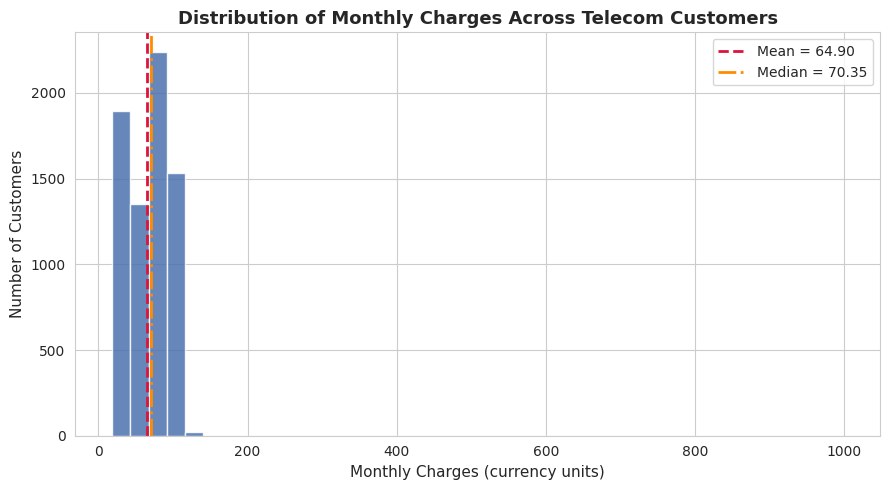

In [93]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df["MonthlyCharges"], bins=40, color="#4C72B0",
        edgecolor="white", alpha=0.85)

# Reference lines for the mean and median
mean_charge   = df["MonthlyCharges"].mean()
median_charge = df["MonthlyCharges"].median()
ax.axvline(mean_charge,   color="crimson",   linestyle="--", linewidth=2,
           label=f"Mean = {mean_charge:.2f}")
ax.axvline(median_charge, color="darkorange", linestyle="-.", linewidth=2,
           label=f"Median = {median_charge:.2f}")

ax.set_title("Distribution of Monthly Charges Across Telecom Customers",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly Charges (currency units)", fontsize=11)
ax.set_ylabel("Number of Customers", fontsize=11)
ax.legend()

plt.tight_layout()
plt.show()

**Observations:**

1. The distribution is **bimodal, not bell-shaped**. A tall isolated
   spike sits near the low end (roughly 18–25), containing about
   **1,389 customers (19.7%)**, and a second broad concentration spans
   roughly 70–110, holding around **3,376 customers**. The middle range
   is comparatively sparse.
2. The **median (70.35) exceeds the mean (64.76)**, which is unusual —
   most skewed data shows the opposite. The low-end spike pulls the mean
   downward while the bulk of customers sit above it, meaning **the mean
   describes no typical customer.** It falls in the sparse gap between
   the two groups.
3. The low-charge spike corresponds to the **1,526 customers with no
   internet service** identified earlier in the category counts. Those
   customers pay for phone service only, which explains a floor near 20
   rather than a smooth tail toward zero.
4. This bimodality is a structural feature of the product range, not a
   data-quality problem. It matters analytically because summary
   statistics assuming a single central tendency would misrepresent this
   variable.

## Plot 2 — Churn Across Contract Types

`Contract` is the ordinal variable in this dataset: Month-to-month →
One year → Two year represents increasing commitment. Since the
analytical question asks which attributes are associated with churn,
comparing churn across these three levels is the most direct test
available.

Two views are shown side by side. The left panel gives absolute counts,
which show how many customers each contract type holds. The right panel
gives percentages within each contract type, which allows fair
comparison despite the groups being very different sizes.

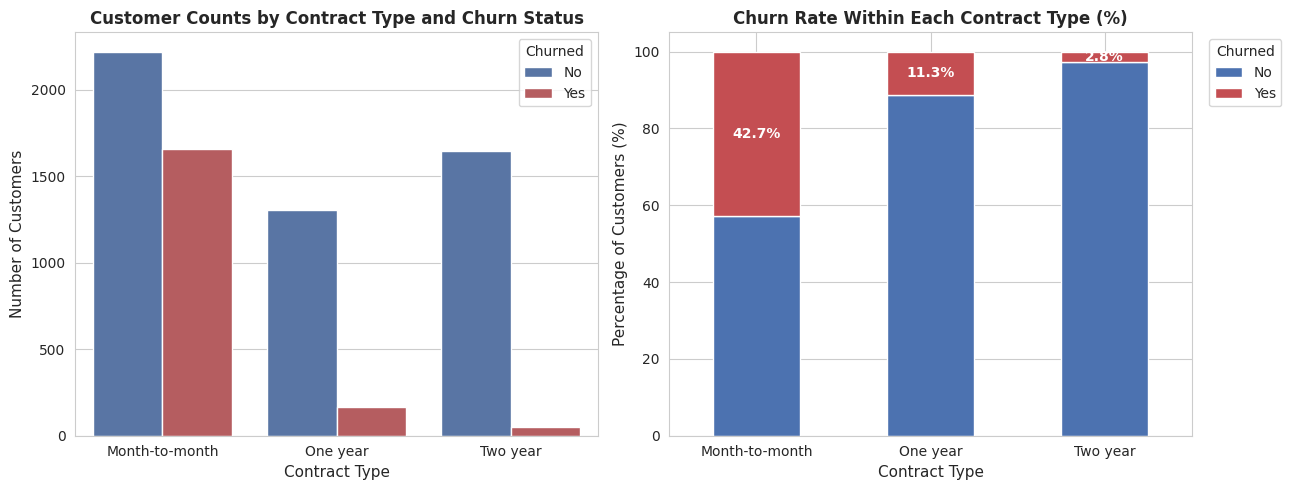

Overall churn rate: 26.5%

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = ["Month-to-month", "One year", "Two year"]   # ordinal sequence

# --- Left: absolute counts ---
sns.countplot(data=df, x="Contract", hue="Churn", order=order,
              palette={"No": "#4C72B0", "Yes": "#C44E52"}, ax=axes[0])
axes[0].set_title("Customer Counts by Contract Type and Churn Status",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Contract Type", fontsize=11)
axes[0].set_ylabel("Number of Customers", fontsize=11)
axes[0].legend(title="Churned")

# --- Right: churn rate within each contract type ---
pct = (pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
       ).loc[order]
pct.plot(kind="bar", stacked=True, ax=axes[1],
         color=["#4C72B0", "#C44E52"], edgecolor="white")
axes[1].set_title("Churn Rate Within Each Contract Type (%)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Contract Type", fontsize=11)
axes[1].set_ylabel("Percentage of Customers (%)", fontsize=11)
axes[1].legend(title="Churned", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

# Annotate the churn percentage on each bar
for i, contract in enumerate(order):
    churn_pct = pct.loc[contract, "Yes"]
    axes[1].text(i, 100 - churn_pct / 2, f"{churn_pct:.1f}%",
                 ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

# Supporting figures
print("Overall churn rate: 26.5%\n")
print(pd.crosstab(df["Contract"], df["Churn"]))

**Observations:**

1. Churn rate falls sharply as contract length increases:
   **42.7% for month-to-month, 11.3% for one-year, and 2.8% for
   two-year** customers. Month-to-month customers churn at roughly
   **15 times** the rate of two-year customers — the largest separation
   found anywhere in this dataset.
2. The two panels tell different stories, which is why both are shown.
   In absolute counts, month-to-month customers dominate churn
   (**1,655 of the 1,869 total churners**, or 88.5%). But that is
   partly because the group is simply the largest at 3,875 customers.
   The percentage view confirms the effect survives after adjusting for
   group size.
3. Against the overall churn rate of **26.5%**, month-to-month customers
   are well above average while both fixed-term groups are far below it.
   The ordinal ordering of the variable is preserved in the outcome:
   each step up in commitment lowers churn, with no reversal.
4. **This is an association, not a demonstrated cause.** Two readings fit
   the same data equally well: a long contract may prevent leaving, or
   customers who already intended to stay may be the ones who choose
   long contracts. This dataset is a single snapshot with no record of
   *when* contracts were chosen relative to churn, so it cannot
   distinguish between the two.

## Plot 3 — Tenure Against Total Charges by Churn Status

The data-quality section established that `TotalCharges` accumulates
with `tenure`, so the two are mechanically linked. Plotting them
together and colouring by churn shows **where along that relationship
churning customers sit**, which neither variable reveals on its own.

A scatter plot suits this because both variables are continuous and the
question concerns their joint behaviour rather than either distribution
separately.

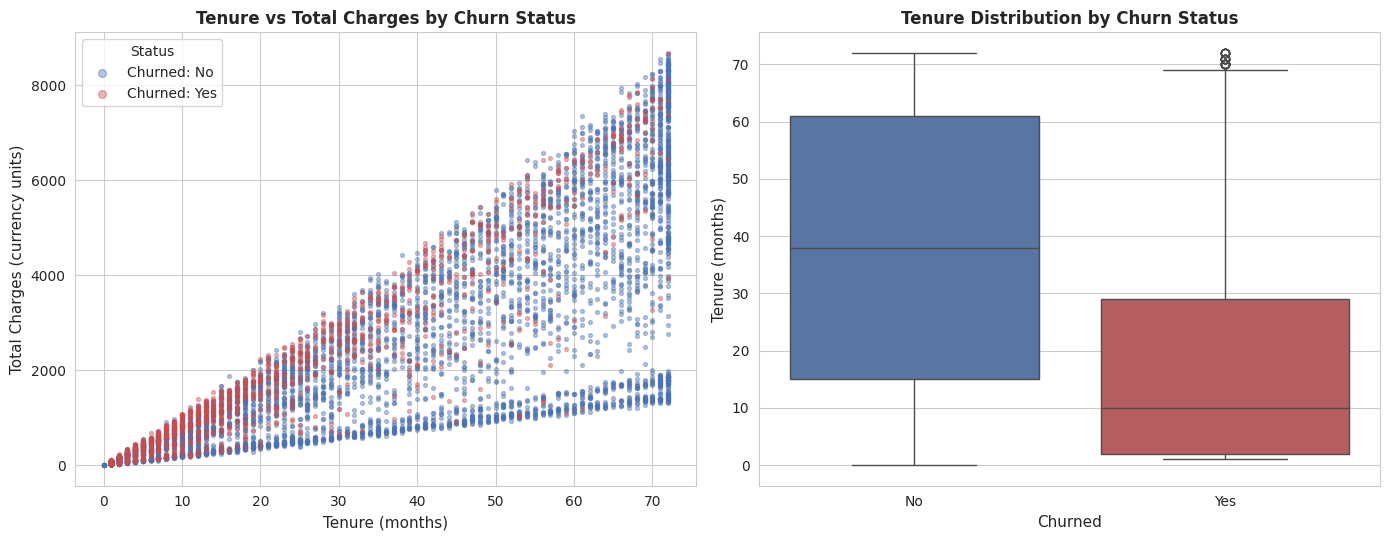

      tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.45  64.45      2549.91  1679.52
Yes    17.98   10.0          74.44  79.65      1531.80   703.55


In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colors = {"No": "#4C72B0", "Yes": "#C44E52"}

# --- Left: scatter of tenure vs total charges ---
for status in ["No", "Yes"]:
    subset = df[df["Churn"] == status]
    axes[0].scatter(subset["tenure"], subset["TotalCharges"],
                    s=8, alpha=0.4, c=colors[status],
                    label=f"Churned: {status}")

axes[0].set_title("Tenure vs Total Charges by Churn Status",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tenure (months)", fontsize=11)
axes[0].set_ylabel("Total Charges (currency units)", fontsize=11)
axes[0].legend(title="Status", markerscale=2)

# --- Right: tenure distribution split by churn ---
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn",
            palette=colors, legend=False, ax=axes[1])
axes[1].set_title("Tenure Distribution by Churn Status",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Churned", fontsize=11)
axes[1].set_ylabel("Tenure (months)", fontsize=11)

plt.tight_layout()
plt.show()

# Supporting figures
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
        .agg(["mean", "median"]).round(2))

**Observations:**

1. The scatter forms a **fan spreading upward from the origin** rather
   than a single line. Total charges rise with tenure, as expected, but
   the spread widens with tenure because customers on different monthly
   rates accumulate at different speeds. The upper and lower edges of
   the fan correspond to the most and least expensive plans.
2. **Churned customers cluster tightly in the lower-left region.** Their
   mean tenure is **18.0 months against 37.6 for retained customers**,
   and the median gap is starker still: **10 months versus 38**. Churn
   is concentrated early in the customer lifetime.
3. The median being far below the mean for churners (10 vs 18) shows
   their tenure distribution is **strongly right-skewed** — a large
   number leave within the first few months, with a thinner tail of
   later departures. The box plot makes this visible as a compressed box
   sitting low on the axis.
4. Churned customers pay **more per month on average (74.44 vs 61.27)**
   yet accumulate **far less in total** — they leave before their
   spending compounds. Higher monthly cost and shorter tenure appear
   together in the same group.
5. **These are associations observed in a snapshot, not causes.** Higher
   charges may drive customers away, or customers on premium plans may
   simply be the ones most willing to switch providers. The data records
   the final state of each customer, not the sequence of events leading
   to it, so no direction can be established.

## Plot 4 (Optional) — Multivariate View Using Plotly

The previous three plots each examined one or two variables. This final
visualisation combines **four** at once: tenure, monthly charges,
contract type, and churn status. Plotly is used here because the chart
is interactive — individual points can be hovered to read a customer's
full record, and the legend can be clicked to isolate groups.

This addresses a limitation of the earlier plots. Contract type and
tenure were each shown to relate to churn separately, but not whether
they act independently or describe the same underlying group of
customers.

In [96]:
# Interactive scatter: tenure vs monthly charges, faceted by contract type
fig = px.scatter(
    df,
    x="tenure",
    y="MonthlyCharges",
    color="Churn",
    facet_col="Contract",
    category_orders={"Contract": ["Month-to-month", "One year", "Two year"],
                     "Churn": ["No", "Yes"]},
    color_discrete_map={"No": "#4C72B0", "Yes": "#C44E52"},
    opacity=0.55,
    hover_data=["InternetService", "PaymentMethod", "TotalCharges"],
    title="Tenure vs Monthly Charges by Contract Type and Churn Status",
    labels={"tenure": "Tenure (months)",
            "MonthlyCharges": "Monthly Charges (currency units)",
            "Churn": "Churned"},
    height=480
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title_text="Churned")
fig.show()

In [97]:
import plotly.io as pio
pio.renderers.default = "colab"

**Observations:**

1. The three panels differ dramatically in **how churn is distributed
   across the tenure axis**. In the month-to-month panel, red points
   crowd the left edge and thin out toward the right. In the two-year
   panel, red points are scarce throughout and scattered rather than
   concentrated.
2. The month-to-month panel shows churn concentrated in the **upper-left
   quadrant** — short tenure combined with high monthly charges. Neither
   variable alone defines the group; it is the combination that marks
   the highest-risk customers. This is only visible when both are
   plotted together.
3. Long-tenure customers appear in all three panels, but they churn at
   visibly different rates depending on contract type. **Tenure and
   contract type are therefore not simply describing the same group** —
   a customer can have long tenure and still sit on a month-to-month
   contract, and those customers churn more than their two-year
   counterparts at equal tenure.
4. The two-year panel is sparse at low tenure, which is a structural
   artefact rather than a finding: a customer cannot have held a
   two-year contract for only three months without it being recorded
   differently. This kind of gap is easy to misread as a pattern, and
   the interactive hover confirms it by showing how few records exist
   there.
5. Hovering reveals `InternetService` and `PaymentMethod` for individual
   points, showing that the high-charge churners are concentrated among
   fiber-optic subscribers — a lead worth following in a future
   analysis, but not established here.

**Note on library choice:** the static plots suit fixed comparisons for
a written report, while Plotly's interactivity suits exploration, where
the useful question is often about a specific point rather than the
overall shape.

# 6. EDA Communication and Findings

## Key Findings

| # | Finding | Evidence |
|---|---|---|
| 1 | Contract type separates churn more sharply than any other variable examined | Churn rate: **42.7%** month-to-month, **11.3%** one-year, **2.8%** two-year, against an overall rate of 26.5% |
| 2 | Churn is concentrated early in the customer lifetime | Median tenure of **10 months** for churners vs **38 months** for retained customers |
| 3 | Churners pay more monthly but contribute less in total | Mean monthly charge **74.44 vs 61.27**; they leave before spending compounds |
| 4 | Monthly charges are bimodal, not normally distributed | A spike of ~1,389 customers near 18–25 (phone-only), and a broad concentration of ~3,376 across 70–110 |
| 5 | Tenure and contract type act as distinct signals | At equal tenure, month-to-month customers still churn more (Plot 4 panels) |
| 6 | The dataset carried a hidden type error | `TotalCharges` stored as text; 11 blank entries, all with `tenure = 0` |

The highest-risk profile combines **short tenure, a month-to-month
contract, and above-average monthly charges** — visible as the crowded
upper-left region of the month-to-month panel in Plot 4.

---

## Can the Analytical Question Be Answered?

The question asked: *which customer attributes are most strongly
associated with churn in a telecom subscriber base?*

**Partly, and with an important qualification.** The data supports
ranking attributes by strength of association: contract type separates
the groups most sharply, followed by tenure, then monthly charges.
Gender, by contrast, showed a near-even split (3,555 / 3,488) and offers
no separation.

The qualification is that **"associated with" is as far as this data
reaches.** The word *most* in the question is answerable; any implied
*why* is not.

### Observations Versus Assumptions

| Statement | Type | Reason |
|---|---|---|
| Month-to-month customers churn at 42.7% | **Observation** | Directly counted from the data |
| Median churner tenure is 10 months | **Observation** | Directly computed |
| Long contracts *prevent* customers leaving | **Assumption** | Not supported — selection effects fit equally well |
| High charges *drive* customers away | **Assumption** | Direction cannot be established from a snapshot |

The contract finding illustrates the danger clearly. Two explanations
fit the same numbers: a long contract may restrain a customer from
leaving, **or** customers who already intended to stay may be the ones
who choose long contracts. The dataset records no timing information, so
it cannot distinguish between them. **No causal claim is made from this
analysis.**

---

## Limitations

1. **The dataset is a single snapshot, not a time series.** Each row
   records a customer's final state with no history. Without knowing
   whether charges rose *before* a customer left or a contract was
   chosen *after* a service problem, the sequence of events — and
   therefore any causal direction — is unrecoverable.

2. **The churn classes are imbalanced (26.5% vs 73.5%).** Retained
   customers outnumber churners nearly three to one, so absolute counts
   consistently favour the larger group. This is why Plot 2 required a
   percentage view alongside counts; a count-only reading would have
   overstated month-to-month churn simply because that group is largest.

3. **No customer-experience data is present.** There are no complaint
   records, service outages, competitor pricing, or satisfaction scores.
   A customer who left after repeated network failures is
   indistinguishable here from one who found a cheaper provider.

4. **The observation window is capped at 72 months.** Customers at the
   maximum may have been with the company longer, so long-tenure
   behaviour is truncated rather than fully observed.

---

## Follow-up Analysis

1. **Cohort analysis using tenure as a proxy for join time.** Grouping
   customers into tenure bands (0–6, 7–12, 13–24 months and so on) and
   comparing churn rates across bands would show whether risk declines
   steadily with time or drops off after a specific threshold. If a
   threshold exists, it would identify when retention effort matters
   most. This requires no new data.

2. **Controlled comparison of contract type within tenure bands.** Plot 4
   suggested contract type still matters at equal tenure, but only
   visually. Comparing churn rates for month-to-month against two-year
   customers *within the same tenure band* would test whether the
   contract effect survives once customer lifetime is held constant, or
   whether it was partly reflecting tenure all along.

3. **Service-feature analysis.** The hover data in Plot 4 hinted that
   high-charge churners cluster among fiber-optic subscribers.
   Systematically comparing churn across `InternetService`,
   `TechSupport`, and `OnlineSecurity` would test whether specific
   service combinations, rather than price alone, mark the high-risk
   group.

---

## Conclusion

This analysis set out to identify which customer attributes are most
strongly associated with churn. Three emerged clearly.

**Contract type is the strongest signal**, with churn falling from 42.7%
to 2.8% across the ordinal range from month-to-month to two-year.
**Tenure is the second**, with churners leaving at a median of 10 months
against 38 for those retained. **Monthly charges rank third**, with
churners paying more per month yet contributing less overall.

Together these describe a consistent profile: the customer most likely
to leave is **new, uncommitted, and paying above average**. The
multivariate view confirmed that tenure and contract type contribute
separately rather than restating one another.

The analysis also demonstrated why exploration precedes modelling. A
routine missing-value check reported a clean dataset, yet `TotalCharges`
was silently stored as text and would have failed or misled any
numerical work built on top of it. Equally, `MonthlyCharges` proved
bimodal, meaning its mean of 64.76 describes no typical customer at all
— it falls in the sparse gap between two distinct groups.

These findings identify **where** churn concentrates. They do not
establish **why**. The dataset is a snapshot without history, and every
pattern reported here is an association observed at a single point in
time. Determining causes would require longitudinal data tracking
customers through the events preceding their decision to leave — which
is precisely what a follow-up study should collect.